# Processing LLM-VLM Results
Analysis of LLM-VLM predictions compared to ground truth and human predictions

In [1]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy import stats

## Load LLM-VLM Predictions
Load predictions from CSV files and aggregate by video using two methods:
1. Mode prediction (most common prediction across frames)
2. Last frame prediction (prediction from the last timestamp)

In [2]:
def load_llm_vlm_results(directory):
    """
    Load LLM-VLM predictions and aggregate by video using:
    1. Mode prediction (most common prediction)
    2. Last frame prediction
    """
    all_predictions = pd.DataFrame()
    mode_predictions = pd.DataFrame()
    last_predictions = pd.DataFrame()
    
    for filename in os.listdir(directory):
        if filename.startswith('predictions_') and filename.endswith('.csv'):
            filepath = os.path.join(directory, filename)
            print(f"Loading {filename}...")
            
            df = pd.read_csv(filepath)
            
            # Extract model name from filename
            model_name = filename.replace('predictions_', '').replace('.csv', '')
            df['model'] = model_name
            
            # Ensure VIDEO column has consistent format (add .mp4 if not present)
            df['video_name'] = df['VIDEO'].apply(lambda x: x + '.mp4' if not str(x).endswith('.mp4') else str(x))
            
            # Convert predictions to numeric (1 = poorly, 0 = well)
            df['prediction_numeric'] = df['PREDICTION'].apply(
                lambda x: 1 if 'poorly' in str(x).lower() else (0 if 'well' in str(x).lower() else np.nan)
            )
            
            # Remove any NaN predictions
            df = df.dropna(subset=['prediction_numeric'])
            
            # Store all predictions
            all_predictions = pd.concat([all_predictions, df], ignore_index=True)
            
            # METHOD 1: Mode prediction (most common prediction per video)
            df_mode = df.groupby('video_name').agg({
                'prediction_numeric': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
                'model': 'first'
            }).reset_index()
            df_mode = df_mode.rename(columns={'prediction_numeric': 'prediction_mode'})
            mode_predictions = pd.concat([mode_predictions, df_mode], ignore_index=True)
            
            # METHOD 2: Last frame prediction
            df_last = df.sort_values('TIME_START').groupby('video_name').tail(1)[['video_name', 'prediction_numeric', 'model']]
            df_last = df_last.rename(columns={'prediction_numeric': 'prediction_last'})
            last_predictions = pd.concat([last_predictions, df_last], ignore_index=True)
            
            print(f"  {model_name}: {df['video_name'].nunique()} unique videos, {len(df)} total predictions")
    
    return all_predictions, mode_predictions, last_predictions

# Load the data
all_preds, mode_preds, last_preds = load_llm_vlm_results('.')

print(f"\nTotal predictions loaded: {len(all_preds)}")
print(f"Mode predictions: {len(mode_preds)} (unique videos per model)")
print(f"Last predictions: {len(last_preds)} (unique videos per model)")

Loading predictions_google_gemini_2.5_PRO.csv...
  google_gemini_2.5_PRO: 0 unique videos, 0 total predictions
Loading predictions_google_gemini_2.0_flash.csv...
  google_gemini_2.0_flash: 30 unique videos, 589 total predictions
Loading predictions_google_gemini_2.0_flash_oldprompt.csv...
  google_gemini_2.0_flash_oldprompt: 30 unique videos, 589 total predictions

Total predictions loaded: 1178
Mode predictions: 60 (unique videos per model)
Last predictions: 60 (unique videos per model)


In [3]:
# Display sample of mode predictions
print("\nSample of mode predictions:")
print(mode_preds.head(10))

print("\nSample of last frame predictions:")
print(last_preds.head(10))


Sample of mode predictions:
     video_name  prediction_mode                    model
0  11_final.mp4              1.0  google_gemini_2.0_flash
1  12_final.mp4              1.0  google_gemini_2.0_flash
2  14_final.mp4              0.0  google_gemini_2.0_flash
3  15_final.mp4              0.0  google_gemini_2.0_flash
4  19_final.mp4              1.0  google_gemini_2.0_flash
5  21_final.mp4              1.0  google_gemini_2.0_flash
6  22_final.mp4              1.0  google_gemini_2.0_flash
7  24_final.mp4              1.0  google_gemini_2.0_flash
8  29_final.mp4              1.0  google_gemini_2.0_flash
9  30_final.mp4              1.0  google_gemini_2.0_flash

Sample of last frame predictions:
     video_name  prediction_last                    model
0   6_final.mp4              1.0  google_gemini_2.0_flash
1  22_final.mp4              1.0  google_gemini_2.0_flash
2  34_final.mp4              1.0  google_gemini_2.0_flash
3  12_final.mp4              1.0  google_gemini_2.0_flash
4  29_fi

## Load Ground Truth Data

In [5]:
# Load ground truth
gt_df = pd.read_csv('../dataset_scenarios/analyze_predictions.csv')

# Create mapping from video name to true outcome
gt_df = gt_df[['Video', 'True Outcome']].rename(columns={'Video': 'video_name', 'True Outcome': 'true_outcome'})
gt_df['video_name'] = gt_df['video_name'].apply(lambda x: x + '.mp4' if not x.endswith('.mp4') else x)
gt_df['true_outcome'] = gt_df['true_outcome'].astype(int)

# Create dictionary for mapping
gt_dict = dict(zip(gt_df['video_name'], gt_df['true_outcome']))

print(f"Loaded ground truth for {len(gt_dict)} videos")
print(f"Sample: {dict(list(gt_dict.items())[:5])}")

Loaded ground truth for 30 videos
Sample: {'6_final.mp4': 1, '7_final.mp4': 1, '9_final.mp4': 1, '11_final.mp4': 1, '12_final.mp4': 1}


## Add Ground Truth to Predictions

In [6]:
# Add ground truth to mode predictions
mode_preds['true_outcome'] = mode_preds['video_name'].map(gt_dict)

# Add ground truth to last frame predictions
last_preds['true_outcome'] = last_preds['video_name'].map(gt_dict)

# Remove any rows without ground truth
mode_preds = mode_preds.dropna(subset=['true_outcome'])
last_preds = last_preds.dropna(subset=['true_outcome'])

print(f"Mode predictions with ground truth: {len(mode_preds)}")
print(f"Last predictions with ground truth: {len(last_preds)}")

# Save to CSV
mode_preds.to_csv('mode_predictions_with_gt.csv', index=False)
last_preds.to_csv('last_predictions_with_gt.csv', index=False)

print("\nSaved predictions with ground truth to CSV files")

Mode predictions with ground truth: 60
Last predictions with ground truth: 60

Saved predictions with ground truth to CSV files


## Calculate Metrics vs Ground Truth

In [8]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate performance metrics
    """
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    
    # Calculate poorly ratio (ratio of "poorly" predictions)
    poorly_count = (y_pred == 1).sum()
    total_count = len(y_pred)
    metrics['poorly_ratio'] = poorly_count / total_count if total_count > 0 else 0

    print('count of each type in y_pred:', np.bincount(y_pred))
    
    return metrics

# Calculate metrics for MODE predictions
print("="*50)
print("MODE PREDICTION PERFORMANCE vs Ground Truth")
print("="*50)

mode_performance = pd.DataFrame()

for model in mode_preds['model'].unique():
    model_data = mode_preds[mode_preds['model'] == model]
    y_true = model_data['true_outcome'].values
    y_pred = model_data['prediction_mode'].values
    
    metrics = calculate_metrics(y_true, y_pred)
    
    print(f"\nModel: {model}")
    print(f"  Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Precision: {metrics['precision']:.3f}")
    print(f"  Recall: {metrics['recall']:.3f}")
    print(f"  F1 Score: {metrics['f1']:.3f}")
    print(f"  Poorly Ratio: {metrics['poorly_ratio']:.3f}")
    
    metrics['model'] = model
    mode_performance = pd.concat([mode_performance, pd.DataFrame([metrics])], ignore_index=True)

mode_performance = mode_performance[['model', 'accuracy', 'precision', 'recall', 'f1', 'poorly_ratio']]
mode_performance.to_csv('mode_performance_vs_gt.csv', index=False)
print("\n" + "="*50)
print("Mode Performance Summary:")
print(mode_performance.round(3))

MODE PREDICTION PERFORMANCE vs Ground Truth
count of each type in y_pred: [ 7 23]

Model: google_gemini_2.0_flash
  Accuracy: 0.467
  Precision: 0.435
  Recall: 0.769
  F1 Score: 0.556
  Poorly Ratio: 0.767
count of each type in y_pred: [16 14]

Model: google_gemini_2.0_flash_oldprompt
  Accuracy: 0.500
  Precision: 0.429
  Recall: 0.462
  F1 Score: 0.444
  Poorly Ratio: 0.467

Mode Performance Summary:
                               model  accuracy  precision  recall     f1  \
0            google_gemini_2.0_flash     0.467      0.435   0.769  0.556   
1  google_gemini_2.0_flash_oldprompt     0.500      0.429   0.462  0.444   

   poorly_ratio  
0         0.767  
1         0.467  


In [12]:
# Calculate metrics for LAST FRAME predictions
print("="*50)
print("LAST FRAME PREDICTION PERFORMANCE vs Ground Truth")
print("="*50)

last_performance = pd.DataFrame()

for model in last_preds['model'].unique():
    model_data = last_preds[last_preds['model'] == model]
    y_true = model_data['true_outcome'].values
    y_pred = model_data['prediction_last'].values
    
    metrics = calculate_metrics(y_true, y_pred)
    
    print(f"\nModel: {model}")
    print(f"  Accuracy: {metrics['accuracy']:.3f}")
    print(f"  Precision: {metrics['precision']:.3f}")
    print(f"  Recall: {metrics['recall']:.3f}")
    print(f"  F1 Score: {metrics['f1']:.3f}")
    print(f"  Poorly Ratio: {metrics['poorly_ratio']:.3f}")

    
    
    metrics['model'] = model
    last_performance = pd.concat([last_performance, pd.DataFrame([metrics])], ignore_index=True)

last_performance = last_performance[['model', 'accuracy', 'precision', 'recall', 'f1', 'poorly_ratio']]
last_performance.to_csv('last_performance_vs_gt.csv', index=False)
print("\n" + "="*50)
print("Last Frame Performance Summary:")
print(last_performance.round(3))

LAST FRAME PREDICTION PERFORMANCE vs Ground Truth
count of each type in y_pred: [ 6 24]

Model: google_gemini_2.0_flash
  Accuracy: 0.500
  Precision: 0.458
  Recall: 0.846
  F1 Score: 0.595
  Poorly Ratio: 0.800
count of each type in y_pred: [19 11]

Model: google_gemini_2.0_flash_oldprompt
  Accuracy: 0.600
  Precision: 0.545
  Recall: 0.462
  F1 Score: 0.500
  Poorly Ratio: 0.367

Last Frame Performance Summary:
                               model  accuracy  precision  recall     f1  \
0            google_gemini_2.0_flash       0.5      0.458   0.846  0.595   
1  google_gemini_2.0_flash_oldprompt       0.6      0.545   0.462  0.500   

   poorly_ratio  
0         0.800  
1         0.367  


## Load Human Predictions Data

In [14]:
# Load human predictions
human_df = pd.read_csv('../dataset_scenarios/badidea_ground_truth.csv')

# Filter to valid participants (from original notebook)
valid_participant_ids = [1048, 1251, 1483, 1676, 2103, 2313, 2698, 2946, 3157, 3203, 3339, 3882, 
                         5009, 5099, 5124, 5233, 5310, 6488, 7136, 7782, 7797, 8184, 8436, 8758, 
                         8786, 9055, 9385, 9777, 9941]

print(f"Original dataset size: {len(human_df)}")
human_df = human_df[human_df['participant_id'].isin(valid_participant_ids)]
print(f"Filtered dataset size: {len(human_df)}")
print(f"Number of participants: {human_df['participant_id'].nunique()}")

Original dataset size: 865
Filtered dataset size: 865
Number of participants: 29


In [17]:
# Create mappings between question IDs and video names
gt_df_full = pd.read_csv('../dataset_scenarios/analyze_predictions.csv')

# Create mapping from question format (q_X) to video format (X_final.mp4)
question_to_video = dict(zip(gt_df_full['Question Mapping'], gt_df_full['Video']))
print("Question to Video mapping (sample):")
for i, (q, v) in enumerate(list(question_to_video.items())[:5]):
    print(f"   {q} -> {v}")

# Convert to video format with .mp4 extension
question_to_video_with_ext = {q: v + '.mp4' for q, v in question_to_video.items()}

# Create the reverse mapping
video_to_question = {v: q for q, v in question_to_video_with_ext.items()}
print("\nVideo to Question mapping (sample):")
for i, (v, q) in enumerate(list(video_to_question.items())[:5]):
    print(f"   {v} -> {q}")

# Create mapping from question ID to true outcome
question_to_outcome = dict(zip(gt_df_full['Question Mapping'], gt_df_full['True Outcome']))
print(f"\nCreated question to outcome mapping with {len(question_to_outcome)} entries")

Question to Video mapping (sample):
   q_2 -> 6_final
   q_3 -> 7_final
   q_4 -> 9_final
   q_5 -> 11_final
   q_6 -> 12_final

Video to Question mapping (sample):
   6_final.mp4 -> q_2
   7_final.mp4 -> q_3
   9_final.mp4 -> q_4
   11_final.mp4 -> q_5
   12_final.mp4 -> q_6

Created question to outcome mapping with 30 entries


## Calculate Individual Human Performance

In [18]:
# Calculate metrics for each individual human participant
print("="*50)
print("Individual Human Predictions vs True Outcome")
print("="*50)

participant_ids = human_df['participant_id'].unique()

def calculate_metrics_with_auc(y_true, y_pred_prob):
    """
    Calculate metrics including AUC, MSE, and MAE
    """
    y_pred = (np.array(y_pred_prob) >= 0.5).astype(int)
    y_true = np.array(y_true).astype(int)
    
    try:
        auc = roc_auc_score(y_true, y_pred_prob)
    except:
        auc = np.nan
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': auc,
        'mse': np.mean((y_true - y_pred_prob) ** 2),
        'mae': np.mean(np.abs(y_true - y_pred_prob))
    }
    return metrics

human_metrics = {}
for participant_id in participant_ids:
    participant_data = human_df[human_df['participant_id'] == participant_id]
    
    true_outcomes = []
    participant_predictions = []
    
    for _, row in participant_data.iterrows():
        question_id = row['response_video']
        
        if question_id in question_to_outcome:
            true_outcomes.append(question_to_outcome[question_id])
            participant_predictions.append(row['class'])
    
    if len(true_outcomes) > 0:
        human_metrics[participant_id] = calculate_metrics_with_auc(
            np.array(true_outcomes),
            np.array(participant_predictions)
        )

# Calculate average metrics across all participants
avg_human_metrics = {}
std_human_metrics = {}
for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc', 'mse', 'mae']:
    values = [m[metric] for m in human_metrics.values() if not np.isnan(m[metric])]
    avg_human_metrics[metric] = np.mean(values) if values else np.nan
    std_human_metrics[metric] = np.std(values) if values else np.nan

human_df_metrics = pd.DataFrame(avg_human_metrics, index=['Average Individual Human'])
print("\nAverage Individual Human Performance:")
print(human_df_metrics.round(3))

human_df_std = pd.DataFrame(std_human_metrics, index=['Standard Deviation'])
print("\nStandard Deviation of Human Performance:")
print(human_df_std.round(3))

human_accuracies = [metrics['accuracy'] for metrics in human_metrics.values()]
print(f"\nDistribution of individual human accuracy:")
print(f"Min: {min(human_accuracies):.3f}, Max: {max(human_accuracies):.3f}, Mean: {np.mean(human_accuracies):.3f}, Median: {np.median(human_accuracies):.3f}")

Individual Human Predictions vs True Outcome

Average Individual Human Performance:
                          accuracy  precision  recall     f1    auc    mse  \
Average Individual Human     0.621      0.575   0.599  0.579  0.619  0.379   

                            mae  
Average Individual Human  0.379  

Standard Deviation of Human Performance:
                    accuracy  precision  recall     f1    auc    mse    mae
Standard Deviation     0.062      0.086   0.091  0.056  0.057  0.062  0.062

Distribution of individual human accuracy:
Min: 0.500, Max: 0.733, Mean: 0.621, Median: 0.633


## Compare Models vs Individual Humans - MODE Predictions

In [19]:
print("="*50)
print("MODE Predictions vs Individual Human Predictions")
print("="*50)

# Create mapping from video name to model predictions (MODE)
video_to_model_preds_mode = {}
for model in mode_preds['model'].unique():
    model_data = mode_preds[mode_preds['model'] == model]
    model_data = model_data.dropna(subset=['prediction_mode'])
    video_to_model_preds_mode[model] = dict(zip(model_data['video_name'], model_data['prediction_mode']))
    print(f"Model {model}: {len(video_to_model_preds_mode[model])} valid predictions")

# Calculate metrics for each model compared to each participant
model_vs_human_metrics_mode = {}

for model in mode_preds['model'].unique():
    model_vs_human_metrics_mode[model] = {}
    print(f"\nProcessing model: {model}")
    
    for participant_id in participant_ids:
        participant_data = human_df[human_df['participant_id'] == participant_id]
        
        human_preds = []
        model_preds = []
        
        for _, row in participant_data.iterrows():
            question_id = row['response_video']
            
            if question_id in question_to_video_with_ext:
                video_name = question_to_video_with_ext[question_id]
                
                if video_name in video_to_model_preds_mode[model]:
                    model_pred = video_to_model_preds_mode[model][video_name]
                    if not np.isnan(model_pred):
                        human_preds.append(row['class'])
                        model_preds.append(model_pred)
        
        if len(human_preds) > 0:
            try:
                model_vs_human_metrics_mode[model][participant_id] = calculate_metrics_with_auc(
                    np.array(human_preds),
                    np.array(model_preds)
                )
            except Exception as e:
                print(f"   Error for participant {participant_id}: {e}")

# Calculate average metrics for each model vs humans
avg_model_vs_human_mode = {}
std_model_vs_human_mode = {}
for model, participant_metrics in model_vs_human_metrics_mode.items():
    if participant_metrics:
        avg_model_vs_human_mode[model] = {}
        std_model_vs_human_mode[model] = {}
        for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc', 'mse', 'mae']:
            values = [m[metric] for m in participant_metrics.values() if not np.isnan(m[metric])]
            avg_model_vs_human_mode[model][metric] = np.mean(values) if values else np.nan
            std_model_vs_human_mode[model][metric] = np.std(values) if values else np.nan

# Convert to DataFrame
avg_model_vs_human_mode_df = pd.DataFrame(avg_model_vs_human_mode).T
print("\n" + "="*50)
print("RESULTS: MODE Predictions - Average Agreement with Individual Humans")
print("="*50)
print(avg_model_vs_human_mode_df.round(3))

std_model_vs_human_mode_df = pd.DataFrame(std_model_vs_human_mode).T
print("\nStandard Deviation of Agreement with Individual Humans:")
print(std_model_vs_human_mode_df.round(3))

# Save results
avg_model_vs_human_mode_df.to_csv('mode_vs_human_agreement.csv')
print("\nResults saved to 'mode_vs_human_agreement.csv'")

MODE Predictions vs Individual Human Predictions
Model google_gemini_2.0_flash: 30 valid predictions
Model google_gemini_2.0_flash_oldprompt: 30 valid predictions

Processing model: google_gemini_2.0_flash

Processing model: google_gemini_2.0_flash_oldprompt

RESULTS: MODE Predictions - Average Agreement with Individual Humans
                                   accuracy  precision  recall     f1    auc  \
google_gemini_2.0_flash               0.546      0.507   0.844  0.627  0.569   
google_gemini_2.0_flash_oldprompt     0.595      0.564   0.568  0.559  0.597   

                                     mse    mae  
google_gemini_2.0_flash            0.454  0.454  
google_gemini_2.0_flash_oldprompt  0.405  0.405  

Standard Deviation of Agreement with Individual Humans:
                                   accuracy  precision  recall     f1    auc  \
google_gemini_2.0_flash               0.068      0.098   0.062  0.081  0.054   
google_gemini_2.0_flash_oldprompt     0.068      0.137   0.073 

## Compare Models vs Individual Humans - LAST FRAME Predictions

In [20]:
print("="*50)
print("LAST FRAME Predictions vs Individual Human Predictions")
print("="*50)

# Create mapping from video name to model predictions (LAST)
video_to_model_preds_last = {}
for model in last_preds['model'].unique():
    model_data = last_preds[last_preds['model'] == model]
    model_data = model_data.dropna(subset=['prediction_last'])
    video_to_model_preds_last[model] = dict(zip(model_data['video_name'], model_data['prediction_last']))
    print(f"Model {model}: {len(video_to_model_preds_last[model])} valid predictions")

# Calculate metrics for each model compared to each participant
model_vs_human_metrics_last = {}

for model in last_preds['model'].unique():
    model_vs_human_metrics_last[model] = {}
    print(f"\nProcessing model: {model}")
    
    for participant_id in participant_ids:
        participant_data = human_df[human_df['participant_id'] == participant_id]
        
        human_preds = []
        model_preds = []
        
        for _, row in participant_data.iterrows():
            question_id = row['response_video']
            
            if question_id in question_to_video_with_ext:
                video_name = question_to_video_with_ext[question_id]
                
                if video_name in video_to_model_preds_last[model]:
                    model_pred = video_to_model_preds_last[model][video_name]
                    if not np.isnan(model_pred):
                        human_preds.append(row['class'])
                        model_preds.append(model_pred)
        
        if len(human_preds) > 0:
            try:
                model_vs_human_metrics_last[model][participant_id] = calculate_metrics_with_auc(
                    np.array(human_preds),
                    np.array(model_preds)
                )
            except Exception as e:
                print(f"   Error for participant {participant_id}: {e}")

# Calculate average metrics for each model vs humans
avg_model_vs_human_last = {}
std_model_vs_human_last = {}
for model, participant_metrics in model_vs_human_metrics_last.items():
    if participant_metrics:
        avg_model_vs_human_last[model] = {}
        std_model_vs_human_last[model] = {}
        for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc', 'mse', 'mae']:
            values = [m[metric] for m in participant_metrics.values() if not np.isnan(m[metric])]
            avg_model_vs_human_last[model][metric] = np.mean(values) if values else np.nan
            std_model_vs_human_last[model][metric] = np.std(values) if values else np.nan

# Convert to DataFrame
avg_model_vs_human_last_df = pd.DataFrame(avg_model_vs_human_last).T
print("\n" + "="*50)
print("RESULTS: LAST FRAME Predictions - Average Agreement with Individual Humans")
print("="*50)
print(avg_model_vs_human_last_df.round(3))

std_model_vs_human_last_df = pd.DataFrame(std_model_vs_human_last).T
print("\nStandard Deviation of Agreement with Individual Humans:")
print(std_model_vs_human_last_df.round(3))

# Save results
avg_model_vs_human_last_df.to_csv('last_vs_human_agreement.csv')
print("\nResults saved to 'last_vs_human_agreement.csv'")

LAST FRAME Predictions vs Individual Human Predictions
Model google_gemini_2.0_flash: 30 valid predictions
Model google_gemini_2.0_flash_oldprompt: 30 valid predictions

Processing model: google_gemini_2.0_flash

Processing model: google_gemini_2.0_flash_oldprompt

RESULTS: LAST FRAME Predictions - Average Agreement with Individual Humans
                                   accuracy  precision  recall     f1    auc  \
google_gemini_2.0_flash               0.521      0.491   0.850  0.616  0.545   
google_gemini_2.0_flash_oldprompt     0.563      0.538   0.425  0.469  0.556   

                                     mse    mae  
google_gemini_2.0_flash            0.479  0.479  
google_gemini_2.0_flash_oldprompt  0.437  0.437  

Standard Deviation of Agreement with Individual Humans:
                                   accuracy  precision  recall     f1    auc  \
google_gemini_2.0_flash               0.071      0.098   0.057  0.083  0.049   
google_gemini_2.0_flash_oldprompt     0.067      0.

## Summary Comparison

In [21]:
print("="*80)
print("SUMMARY: Comparison of MODE vs LAST FRAME Predictions")
print("="*80)

print("\n" + "="*80)
print("Performance vs Ground Truth")
print("="*80)

print("\nMODE Predictions:")
print(mode_performance[['model', 'accuracy', 'precision', 'recall', 'f1']].round(3))

print("\nLAST FRAME Predictions:")
print(last_performance[['model', 'accuracy', 'precision', 'recall', 'f1']].round(3))

print("\n" + "="*80)
print("Agreement with Individual Humans")
print("="*80)

print("\nMODE Predictions:")
print(avg_model_vs_human_mode_df[['accuracy', 'precision', 'recall', 'f1']].round(3))

print("\nLAST FRAME Predictions:")
print(avg_model_vs_human_last_df[['accuracy', 'precision', 'recall', 'f1']].round(3))

print("\n" + "="*80)
print("Human Baseline (for reference)")
print("="*80)
print(human_df_metrics[['accuracy', 'precision', 'recall', 'f1']].round(3))

SUMMARY: Comparison of MODE vs LAST FRAME Predictions

Performance vs Ground Truth

MODE Predictions:
                               model  accuracy  precision  recall     f1
0            google_gemini_2.0_flash     0.467      0.435   0.769  0.556
1  google_gemini_2.0_flash_oldprompt     0.500      0.429   0.462  0.444

LAST FRAME Predictions:
                               model  accuracy  precision  recall     f1
0            google_gemini_2.0_flash       0.5      0.458   0.846  0.595
1  google_gemini_2.0_flash_oldprompt       0.6      0.545   0.462  0.500

Agreement with Individual Humans

MODE Predictions:
                                   accuracy  precision  recall     f1
google_gemini_2.0_flash               0.546      0.507   0.844  0.627
google_gemini_2.0_flash_oldprompt     0.595      0.564   0.568  0.559

LAST FRAME Predictions:
                                   accuracy  precision  recall     f1
google_gemini_2.0_flash               0.521      0.491   0.850  0.616
google_

## Visualization

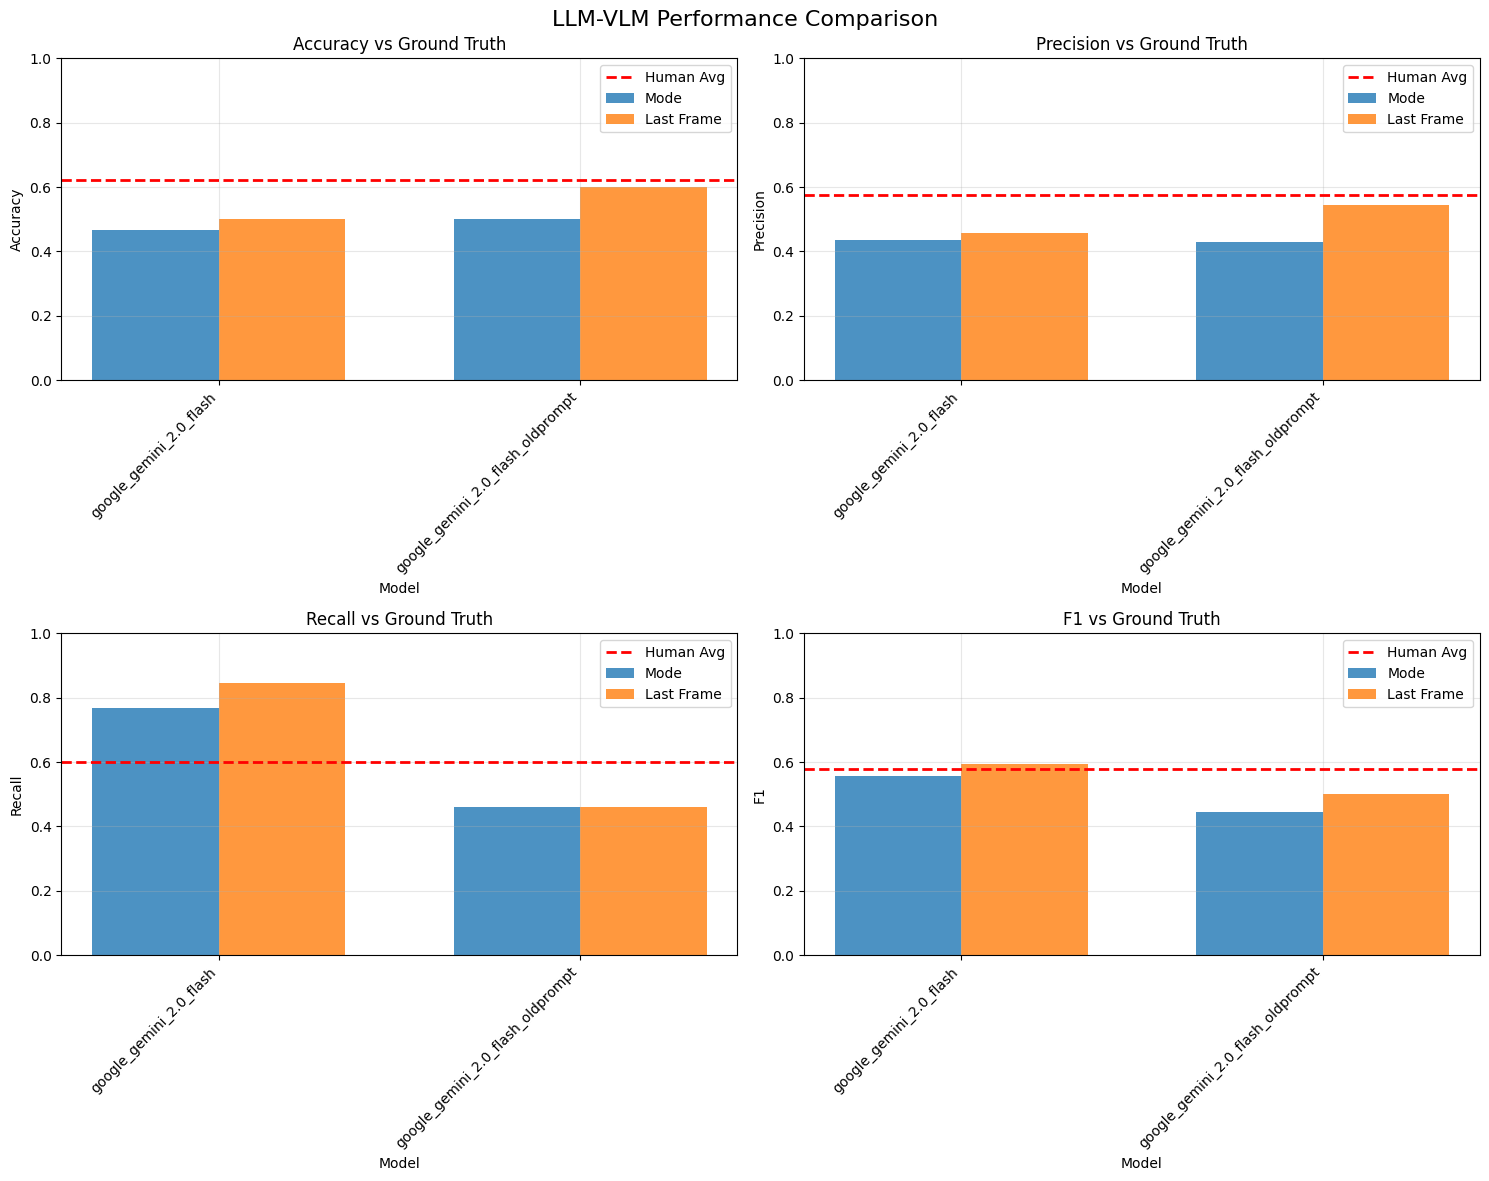


Visualization saved to 'llm_vlm_performance_comparison.png'


In [22]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('LLM-VLM Performance Comparison', fontsize=16)

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Get data for plotting
    models = mode_performance['model'].tolist()
    mode_values = mode_performance[metric].tolist()
    last_values = last_performance[metric].tolist()
    
    x = np.arange(len(models))
    width = 0.35
    
    # Plot bars
    bars1 = ax.bar(x - width/2, mode_values, width, label='Mode', alpha=0.8)
    bars2 = ax.bar(x + width/2, last_values, width, label='Last Frame', alpha=0.8)
    
    # Add human baseline
    human_value = avg_human_metrics[metric]
    ax.axhline(y=human_value, color='red', linestyle='--', label='Human Avg', linewidth=2)
    
    ax.set_xlabel('Model')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()} vs Ground Truth')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('llm_vlm_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved to 'llm_vlm_performance_comparison.png'")